dict_keys(['contactInfo', 'dts', 'generalForces', 'partAs', 'partPq', 'partVs', 'penetrationPairs', 'singleComponentForces', 'timeIndex'])
0.6000000000000002 0.6020000000000002


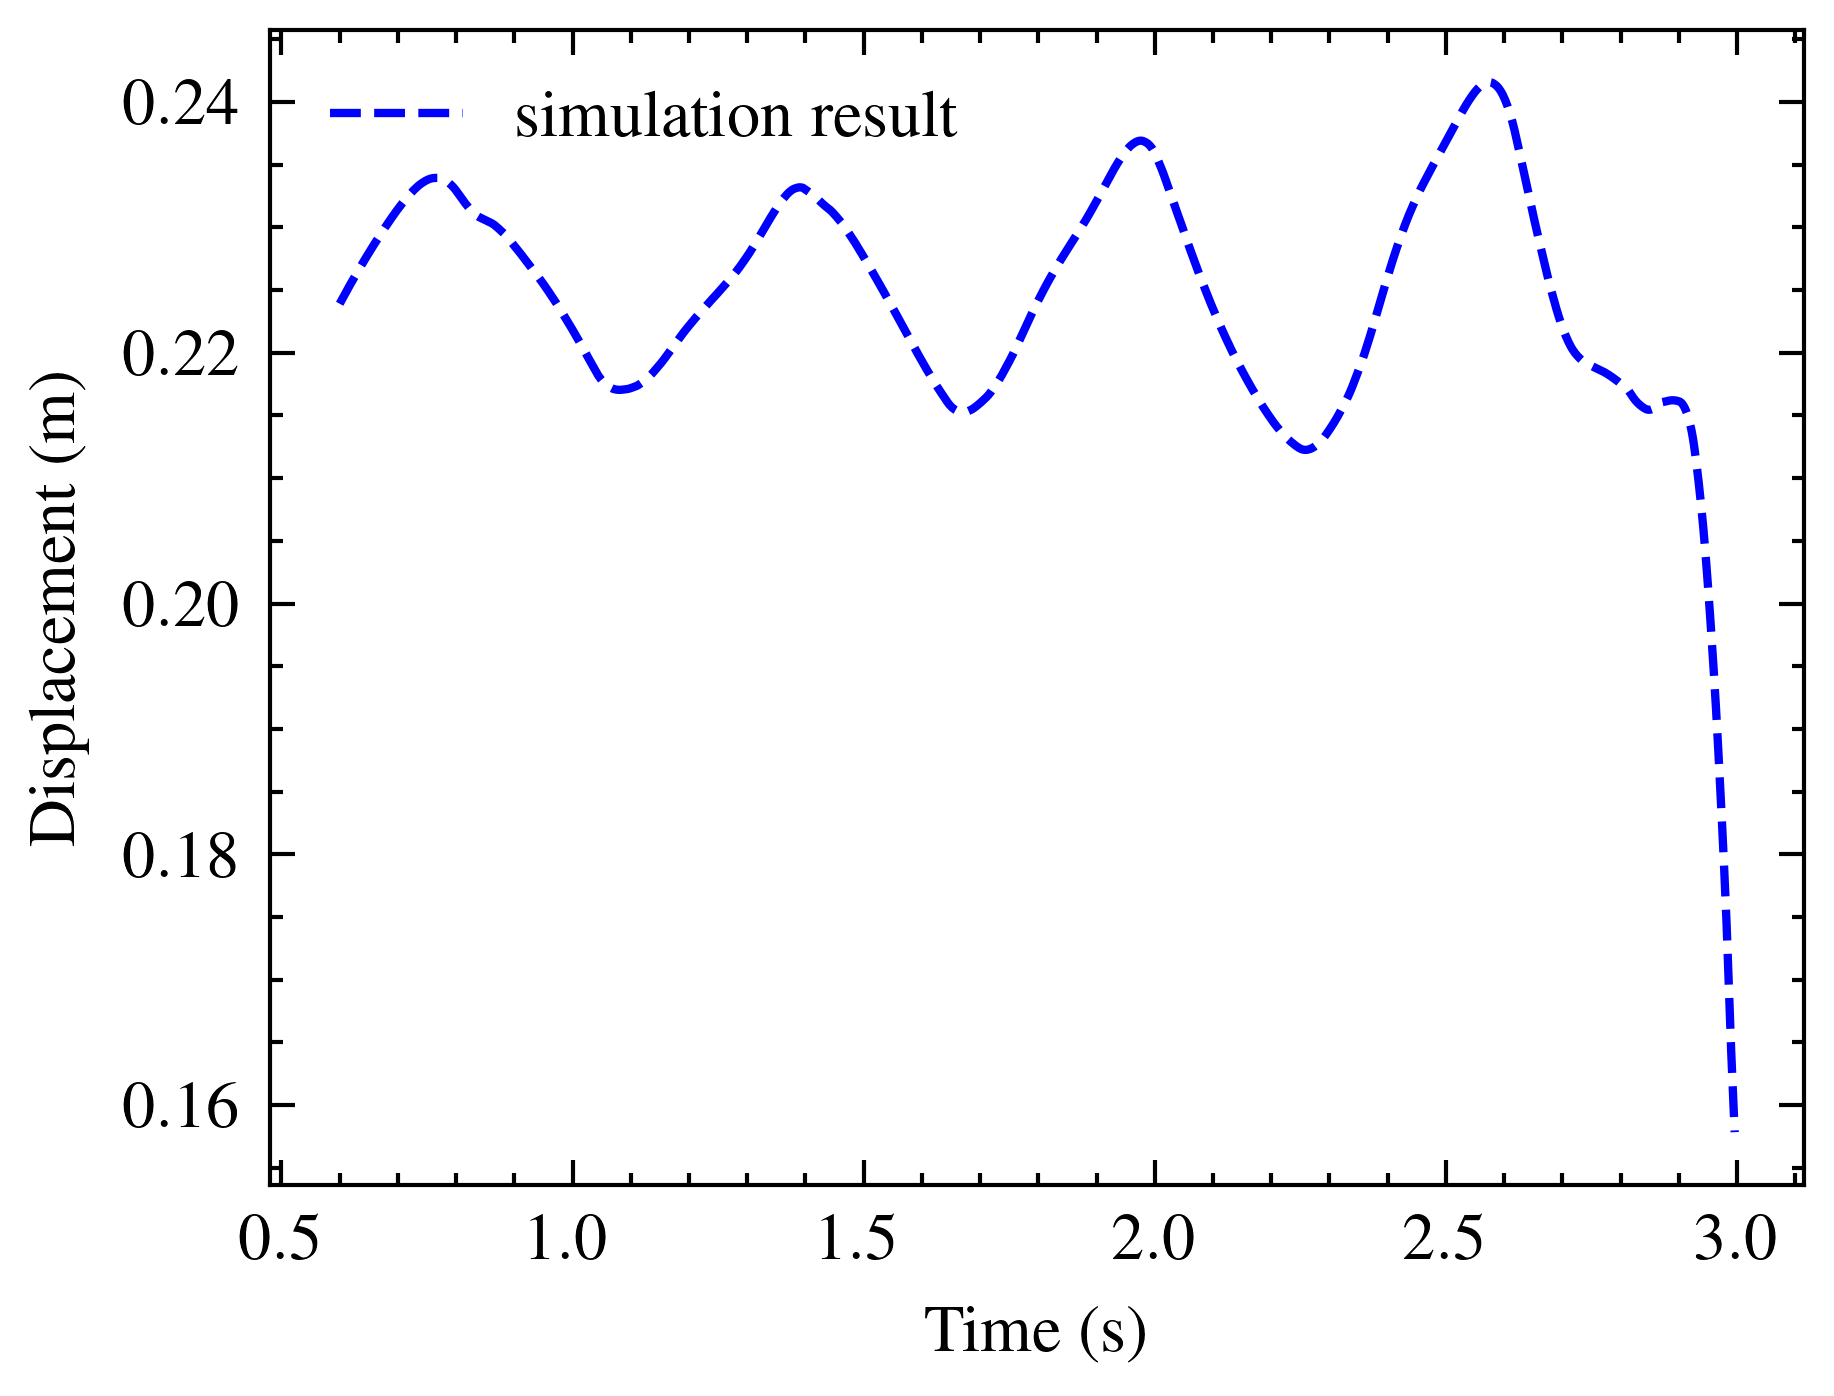

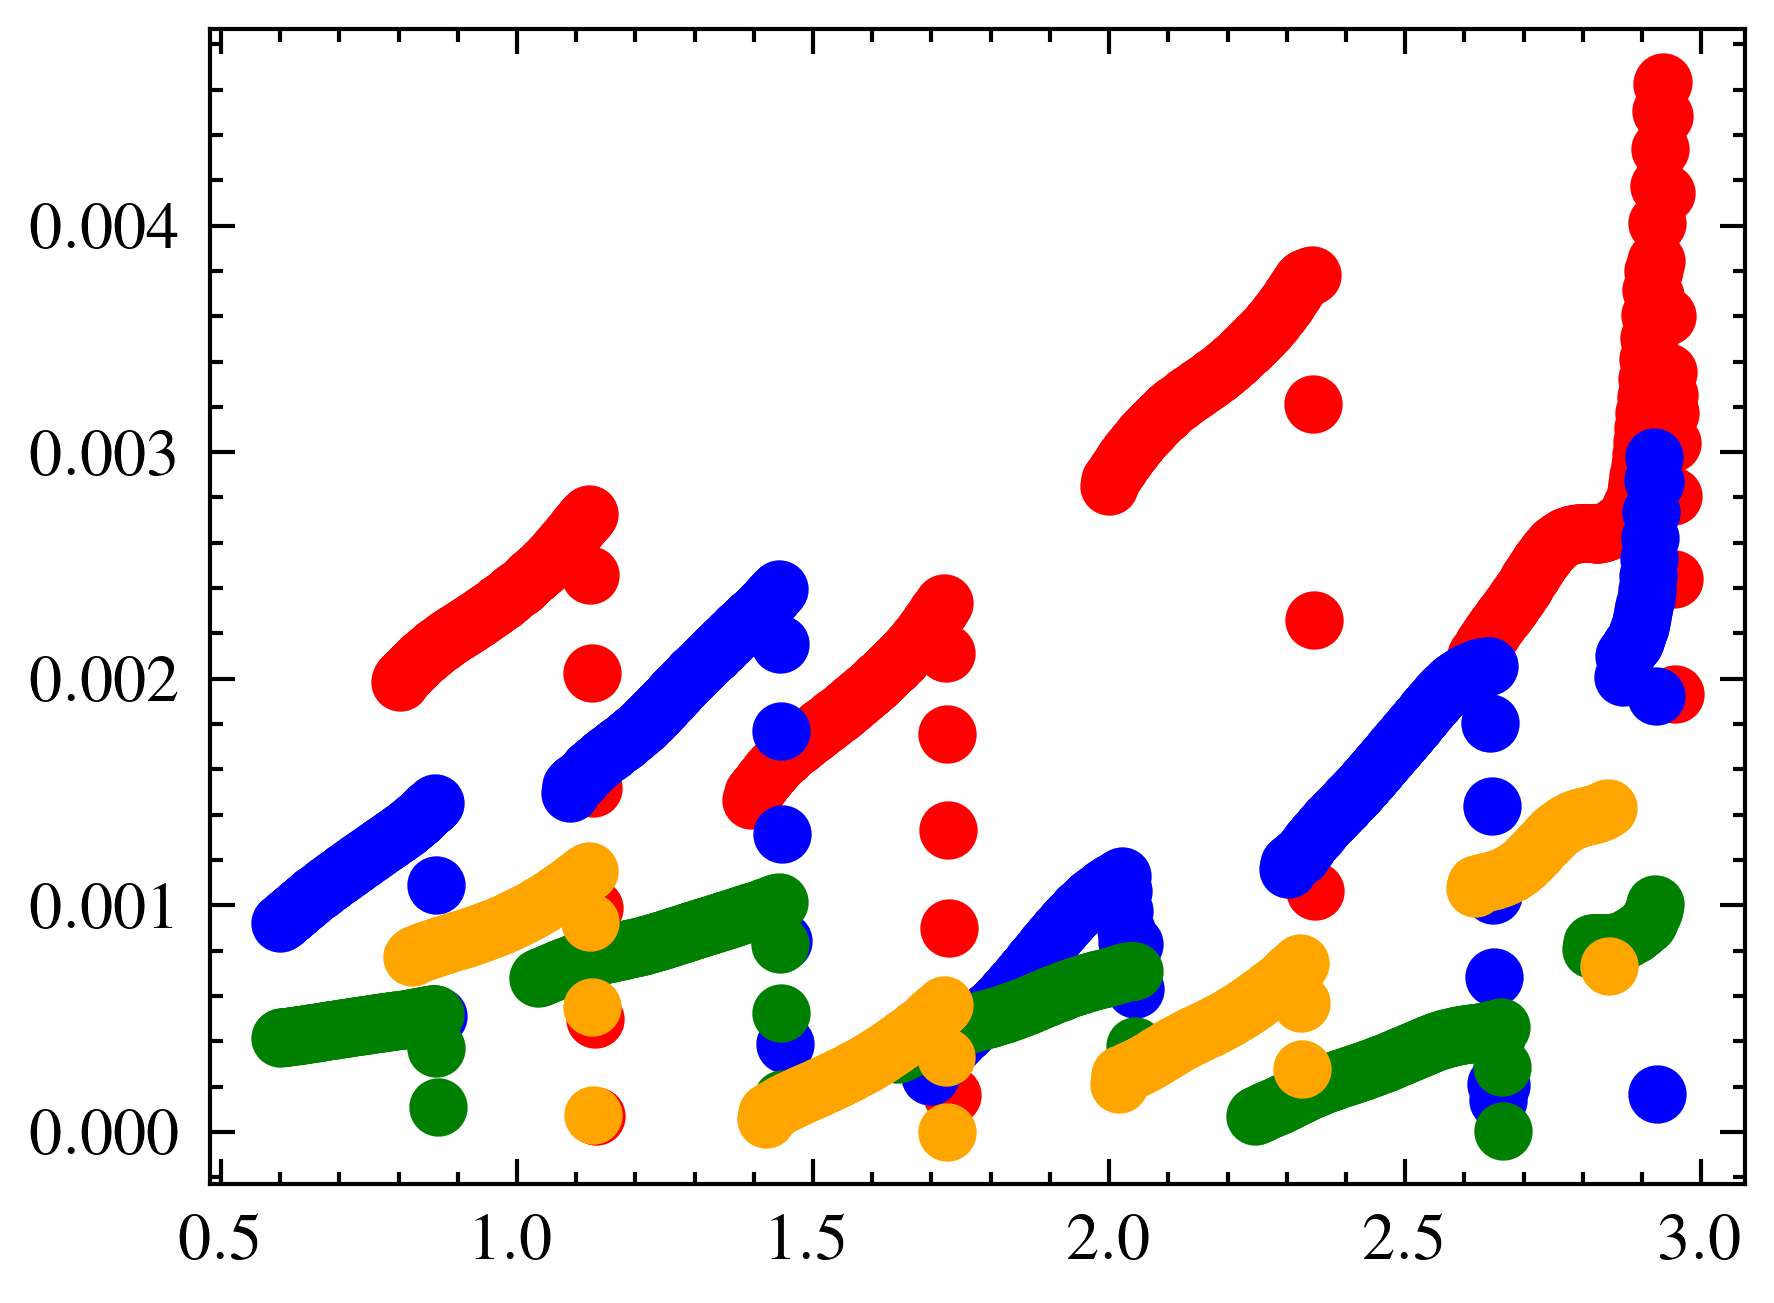

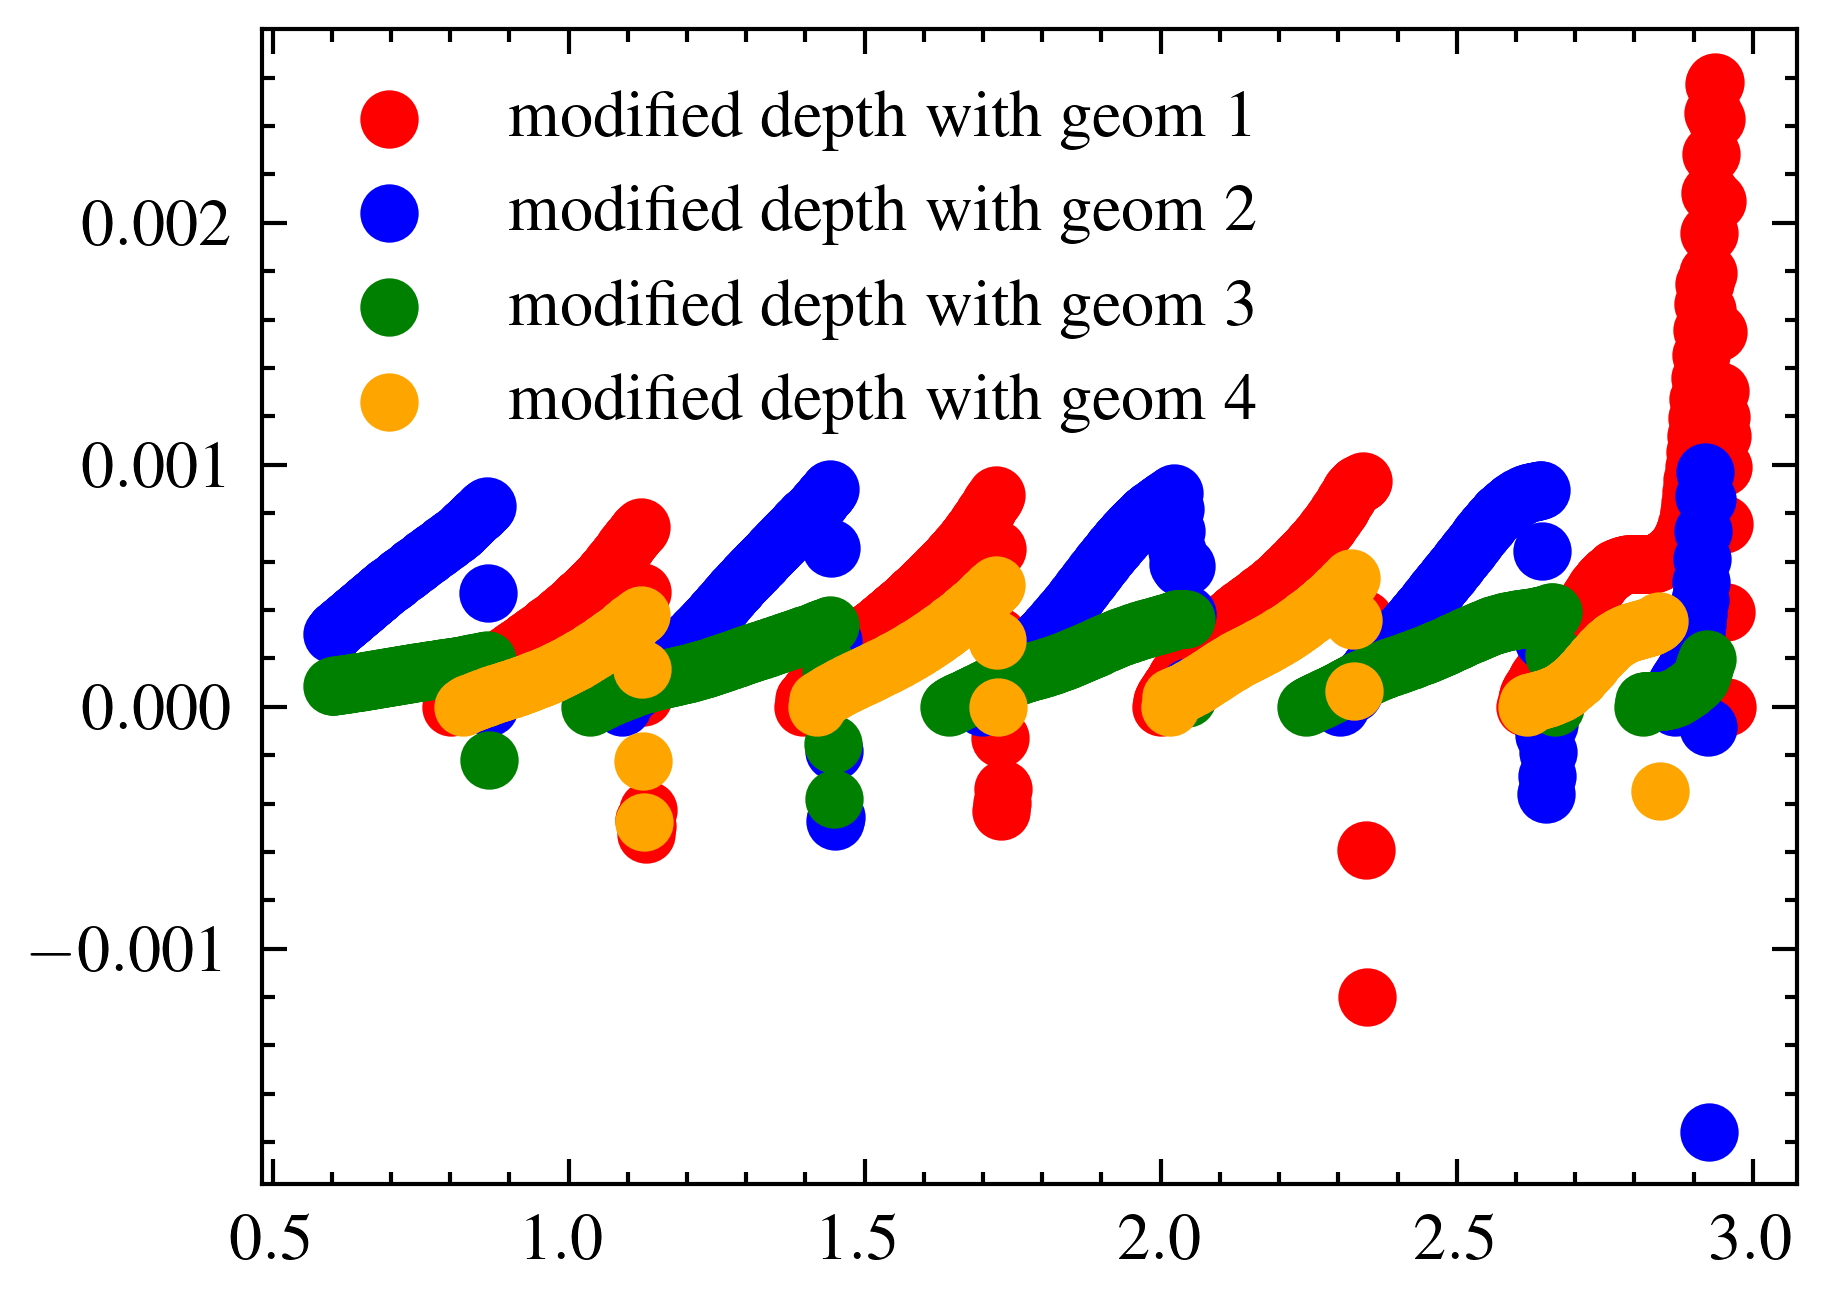

In [3]:
import json
import numpy as np
import sire
import matplotlib.pyplot as plt
import math
import scienceplots

# 读取 JSON 文件
with open("simulation_result.json", "r", encoding="utf-8") as f:
    result = json.load(f)

# 查看顶层 keys
print(result.keys())

plot_time = 3
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
penetrationPairs = result["penetrationPairs"]
dts = result["dts"]
x = []
y = []
t1 = []
c1 = []
t2 = []
c2 = []
t3 = []
c3 = []
t4 = []
c4 = []
modifiedDepthRecord = [[], [], [], []]
yv = []

lowerBound = sire.binarySearch(timeIndices, 0.6)
upperBound = sire.binarySearch(timeIndices, 0 + plot_time)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound-1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  if partpq[i] is not None:
    x.append(timeIndices[i])
    pm = sire.pq2tfmatrix(partpq[i][1])
    yOffset = pm[1, 3]
    zOffset = pm[2, 3]
    y.append(zOffset)  # z position from transformation matrix
  
  if penetrationPairs[i] is not None:
    for pair in penetrationPairs[i]:
      if pair["geomIdB"] == 1:
        t1.append(timeIndices[i])
        c1.append(pair["depth"])
        modifiedDepthRecord[0].append(pair["modifiedDepth"])
      elif pair["geomIdB"] == 2:
        t2.append(timeIndices[i])
        c2.append(pair["depth"])
        modifiedDepthRecord[1].append(pair["modifiedDepth"])
      elif pair["geomIdB"] == 3:
        t3.append(timeIndices[i])
        c3.append(pair["depth"])
        modifiedDepthRecord[2].append(pair["modifiedDepth"])
      elif pair["geomIdB"] == 4:
        t4.append(timeIndices[i])
        c4.append(pair["depth"])
        modifiedDepthRecord[3].append(pair["modifiedDepth"])

  # yv.append(math.sqrt(partvs[i][1][2] ** 2 + partvs[i][1][1]**2))  # z velocity

with plt.style.context(['science','ieee']):
  # plt.plot(x2, y2, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, y, color='blue', linestyle="--", label="simulation result")
  plt.legend()
  plt.xlabel("Time (s)")
  plt.ylabel("Displacement (m)")
  plt.show()
  # plt.plot(x, yv, color='blue', linestyle="--", label="simulation result")
  # plt.xlabel("Time (s)")
  # plt.ylabel("Velocity (m/s)")
  # plt.legend()
  # plt.show()
  plt.scatter(t1, c1, color='red', label="contact with geom 1")
  plt.scatter(t2, c2, color='blue', label="contact with geom 2")
  plt.scatter(t3, c3, color='green', label="contact with geom 3")
  plt.scatter(t4, c4, color='orange', label="contact with geom 4")
  plt.show() 

  plt.scatter(t1, modifiedDepthRecord[0], color='red', label="modified depth with geom 1")
  plt.scatter(t2, modifiedDepthRecord[1], color='blue', label="modified depth with geom 2")
  plt.scatter(t3, modifiedDepthRecord[2], color='green', label="modified  depth with geom 3")
  plt.scatter(t4, modifiedDepthRecord[3], color='orange', label="modified depth with geom 4")
  plt.legend()
  plt.show()

2.800000000000002 2.802000000000002


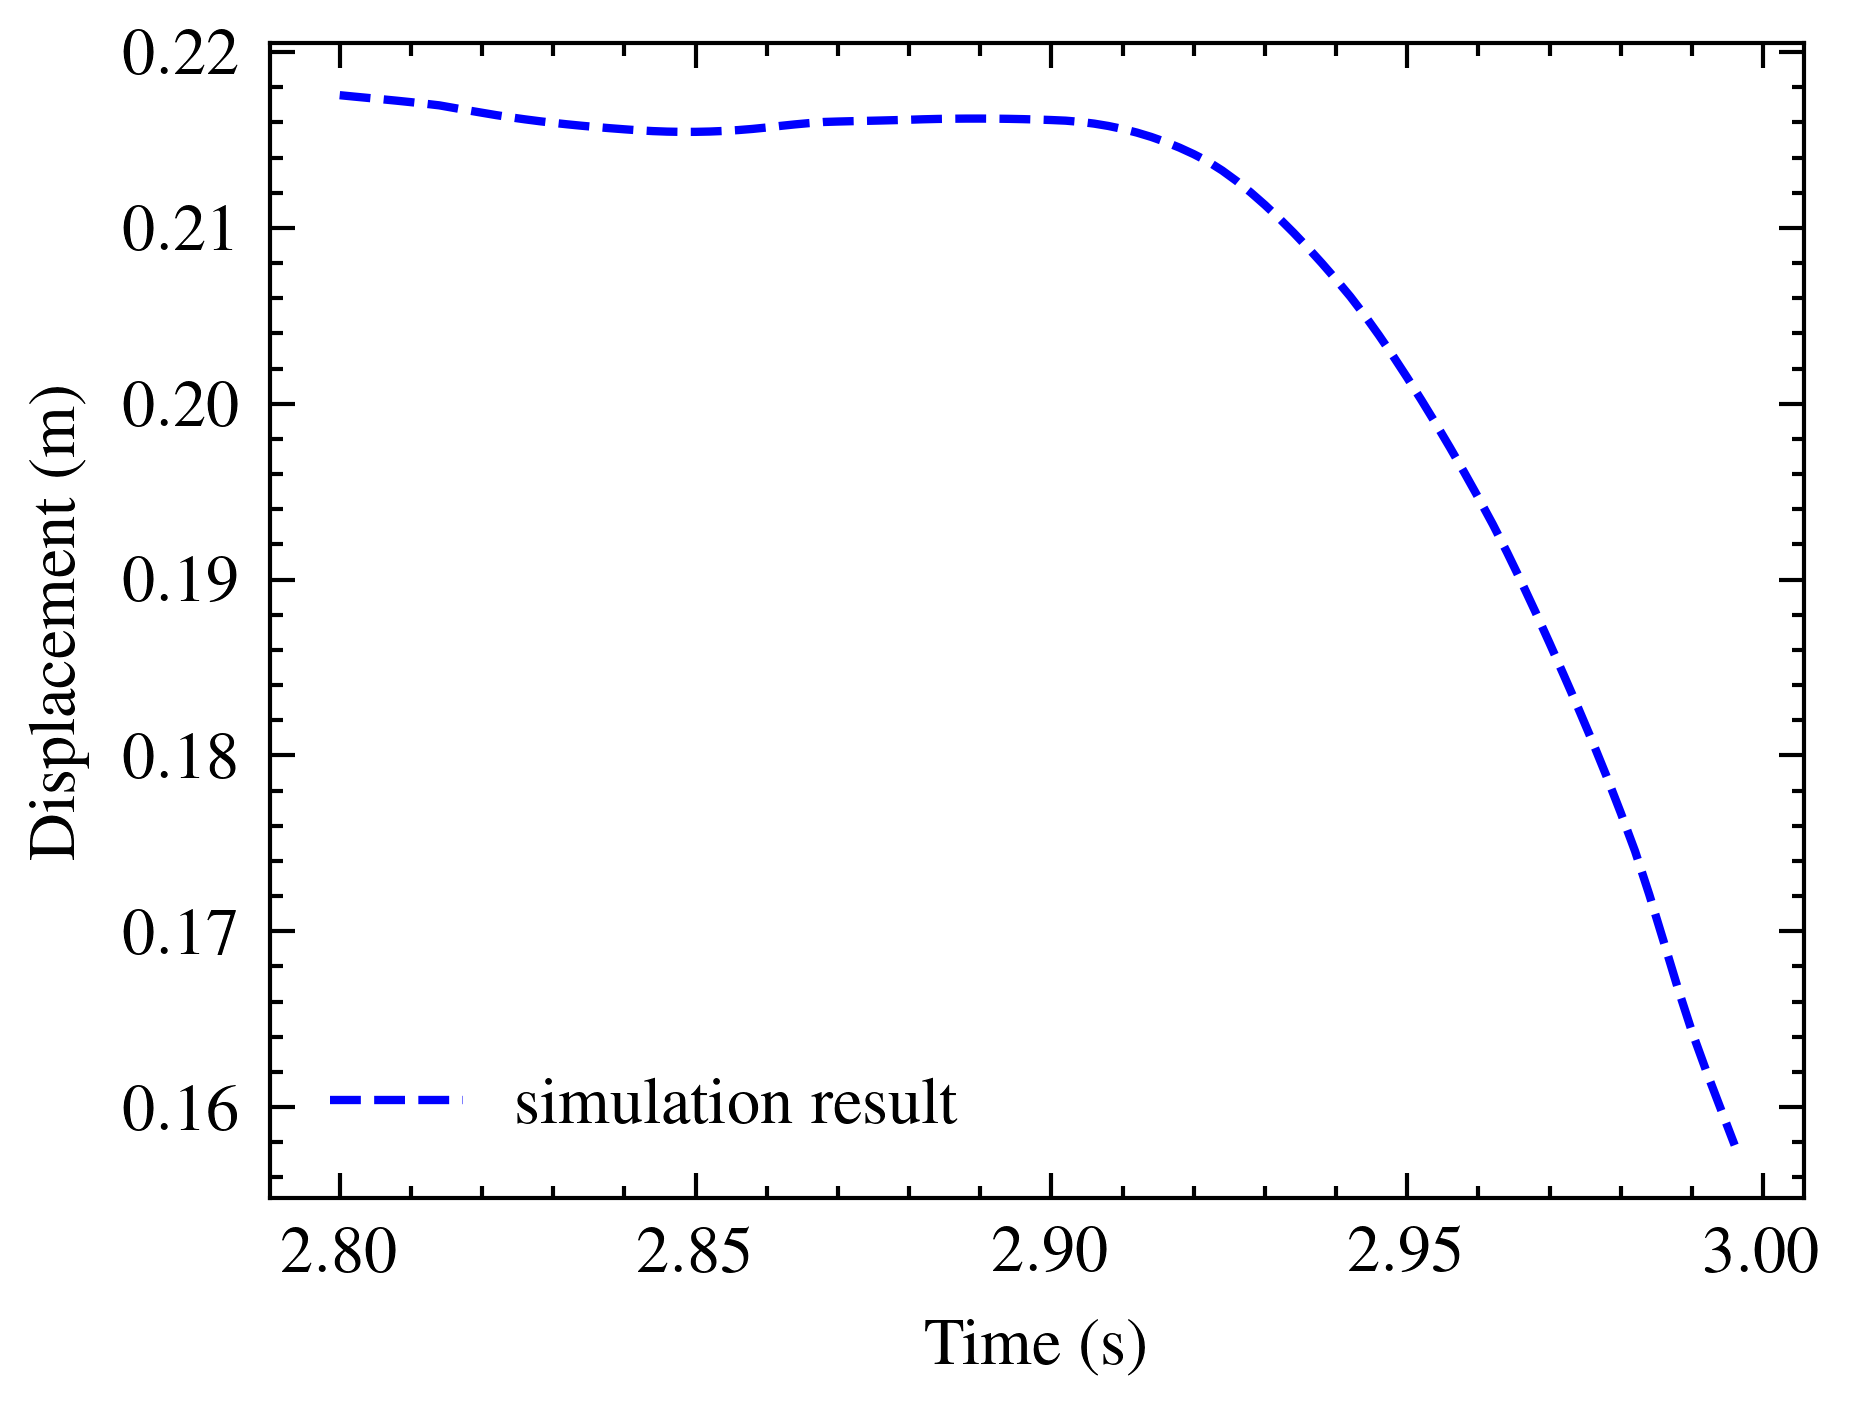

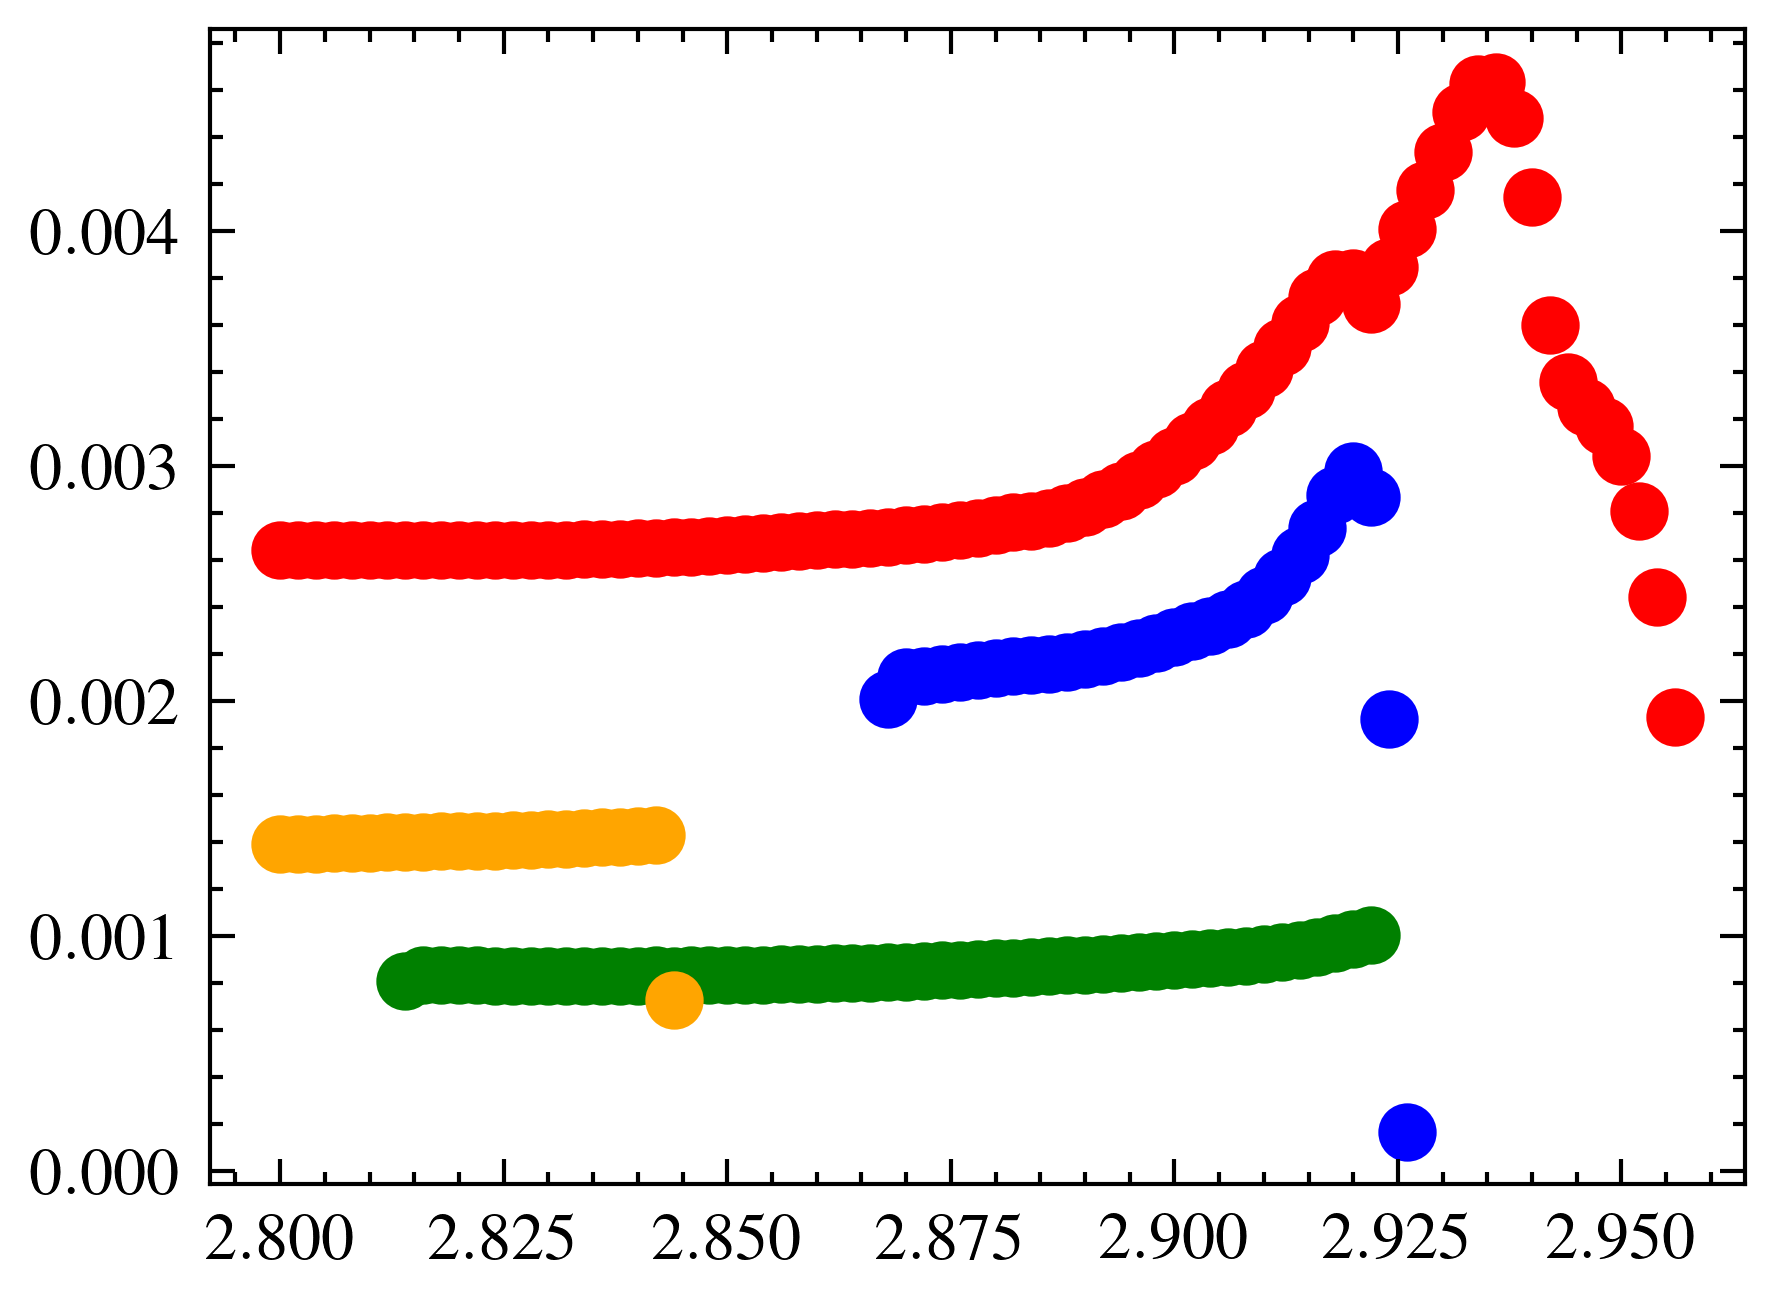

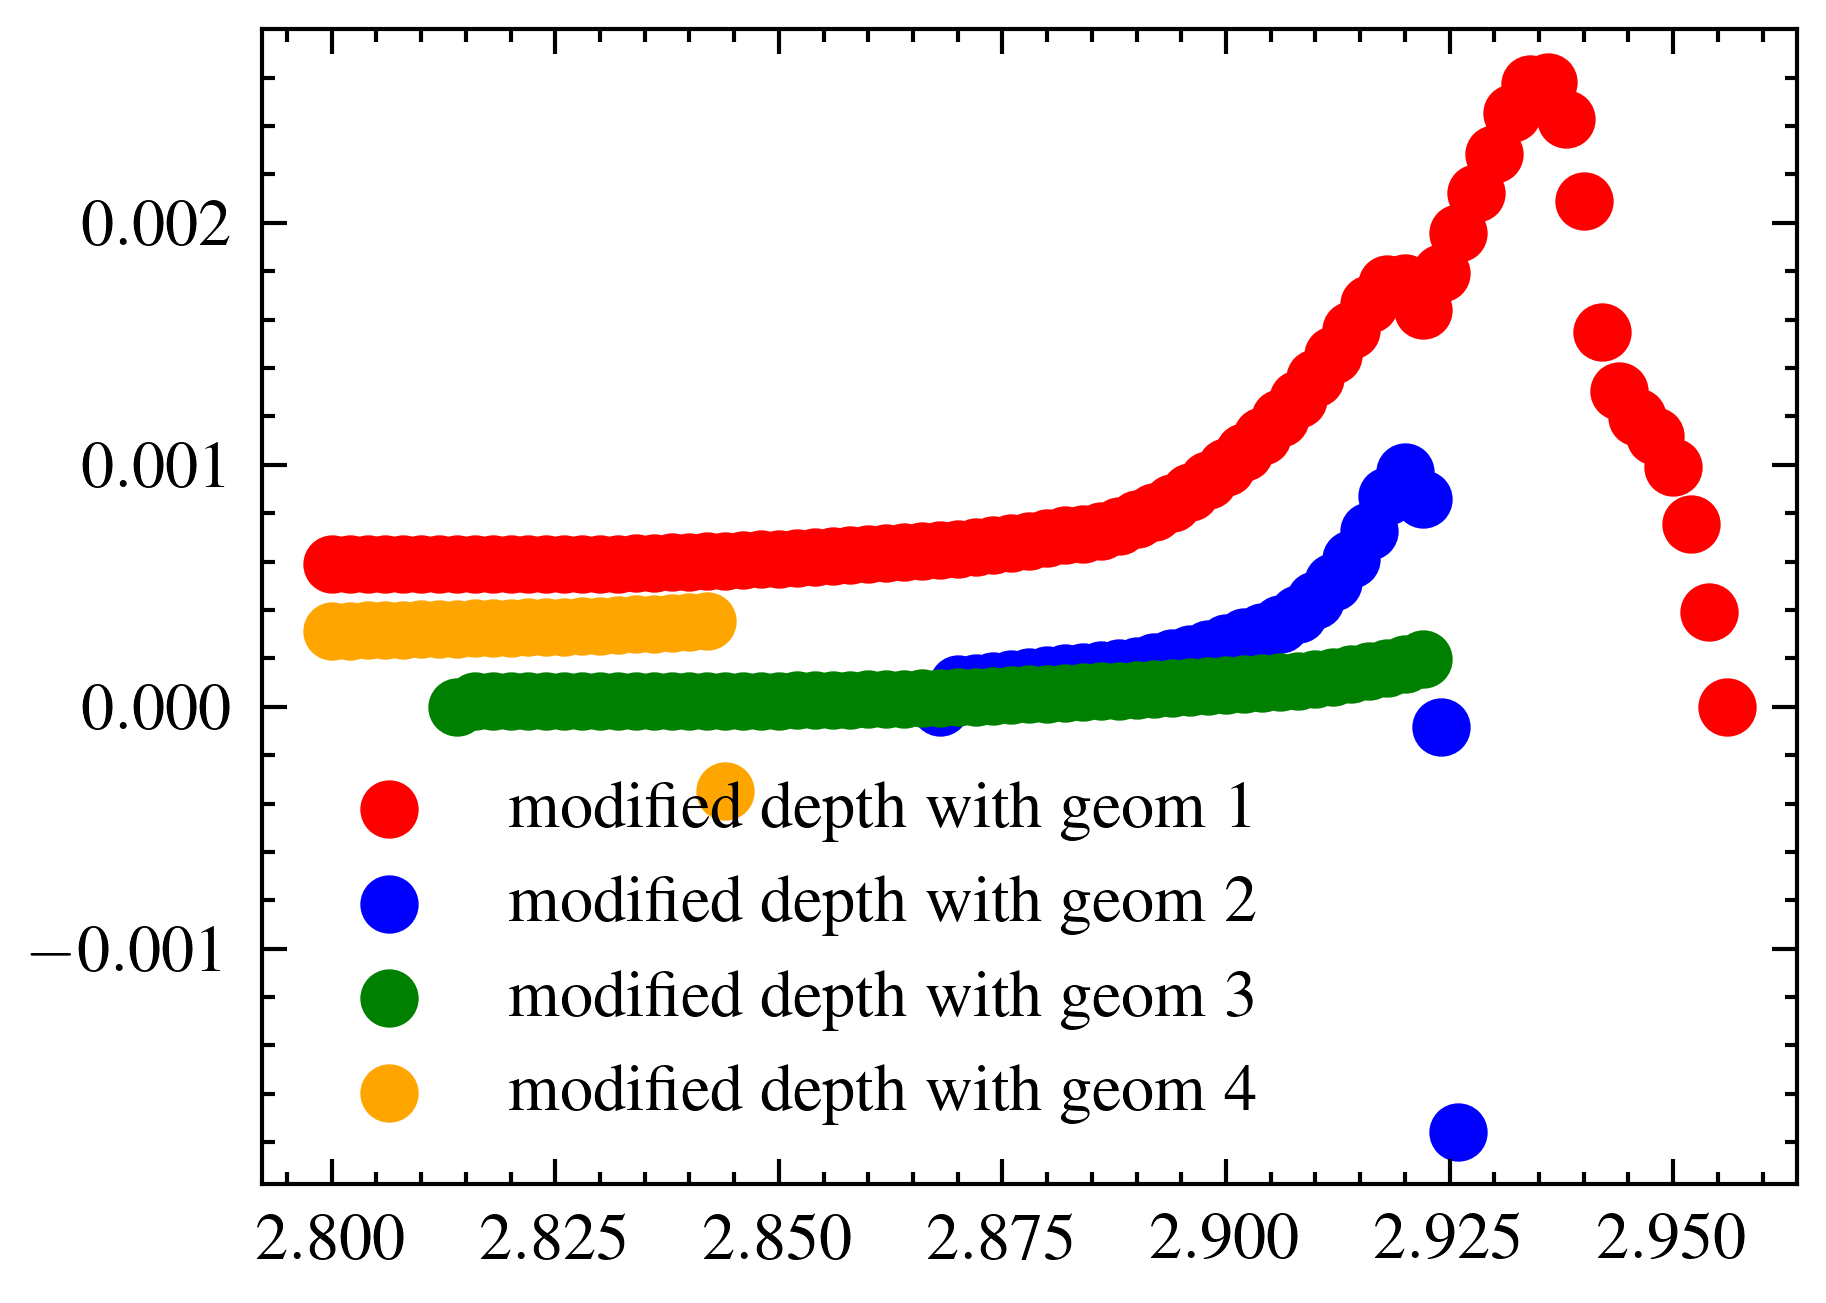

In [4]:
plot_time = 3
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
penetrationPairs = result["penetrationPairs"]
dts = result["dts"]
x = []
y = []
t1 = []
c1 = []
t2 = []
c2 = []
t3 = []
c3 = []
t4 = []
c4 = []
modifiedDepthRecord = [[], [], [], []]
yv = []

lowerBound = sire.binarySearch(timeIndices, 2.8)
upperBound = sire.binarySearch(timeIndices, 0 + plot_time)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound-1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  if partpq[i] is not None:
    x.append(timeIndices[i])
    pm = sire.pq2tfmatrix(partpq[i][1])
    yOffset = pm[1, 3]
    zOffset = pm[2, 3]
    y.append(zOffset)  # z position from transformation matrix
  
  if penetrationPairs[i] is not None:
    for pair in penetrationPairs[i]:
      if pair["geomIdB"] == 1:
        t1.append(timeIndices[i])
        c1.append(pair["depth"])
        modifiedDepthRecord[0].append(pair["modifiedDepth"])
      elif pair["geomIdB"] == 2:
        t2.append(timeIndices[i])
        c2.append(pair["depth"])
        modifiedDepthRecord[1].append(pair["modifiedDepth"])
      elif pair["geomIdB"] == 3:
        t3.append(timeIndices[i])
        c3.append(pair["depth"])
        modifiedDepthRecord[2].append(pair["modifiedDepth"])
      elif pair["geomIdB"] == 4:
        t4.append(timeIndices[i])
        c4.append(pair["depth"])
        modifiedDepthRecord[3].append(pair["modifiedDepth"])

  # yv.append(math.sqrt(partvs[i][1][2] ** 2 + partvs[i][1][1]**2))  # z velocity

with plt.style.context(['science','ieee']):
  # plt.plot(x2, y2, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, y, color='blue', linestyle="--", label="simulation result")
  plt.legend()
  plt.xlabel("Time (s)")
  plt.ylabel("Displacement (m)")
  plt.show()
  # plt.plot(x, yv, color='blue', linestyle="--", label="simulation result")
  # plt.xlabel("Time (s)")
  # plt.ylabel("Velocity (m/s)")
  # plt.legend()
  # plt.show()
  plt.scatter(t1, c1, color='red', label="contact with geom 1")
  plt.scatter(t2, c2, color='blue', label="contact with geom 2")
  plt.scatter(t3, c3, color='green', label="contact with geom 3")
  plt.scatter(t4, c4, color='orange', label="contact with geom 4")
  plt.show() 

  plt.scatter(t1, modifiedDepthRecord[0], color='red', label="modified depth with geom 1")
  plt.scatter(t2, modifiedDepthRecord[1], color='blue', label="modified depth with geom 2")
  plt.scatter(t3, modifiedDepthRecord[2], color='green', label="modified  depth with geom 3")
  plt.scatter(t4, modifiedDepthRecord[3], color='orange', label="modified depth with geom 4")
  plt.legend()
  plt.show()